# Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

## Exercício 1

*   Gere 400 amostras com 2 features e 4 clusters.
*   Plote os dados gerados



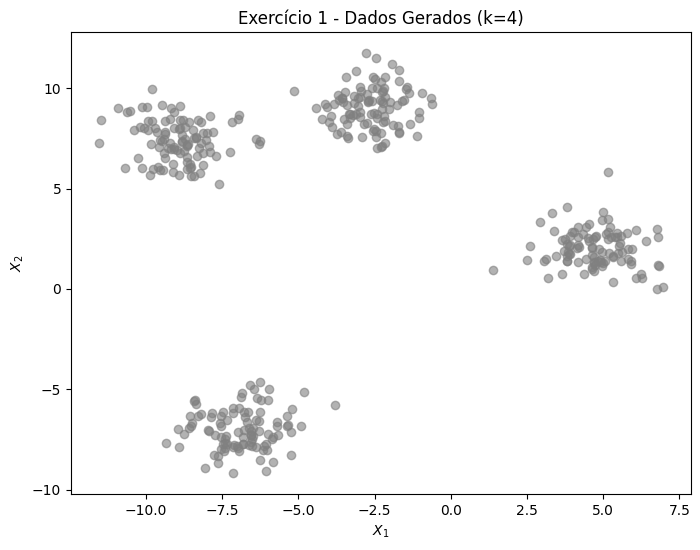

In [3]:
# Gerando os dados artificiais
data, cluster_real = make_blobs(n_samples=400, n_features=2, centers=4, random_state=42)

# Plotando os dados gerados
plt.figure(figsize=(8,6))
plt.scatter(data[:,0], data[:,1], color="gray", alpha=0.6)
plt.title("Exercício 1 - Dados Gerados (k=4)")
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.show()

## Exercício 2

*   Selecionar k amostras aleatórias como centróides iniciais.
*   Tenha cuidado para não selecionar a mesma amostra mais de
uma vez.
*   Plote os centroides no gráfico utilizando símbolos diferentes.

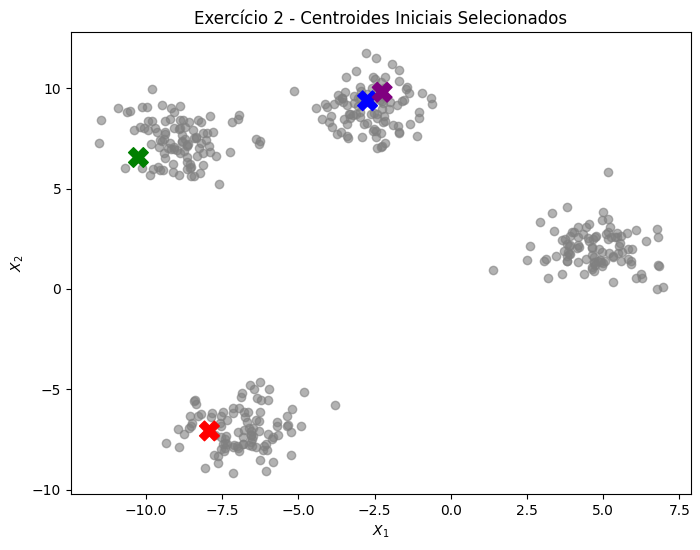

In [5]:
k = 4
np.random.seed(42)
indices_centroides = np.random.choice(range(len(data)), size=k, replace=False)
centroides = data[indices_centroides]

plt.figure(figsize=(8,6))
plt.scatter(data[:,0], data[:,1], c='gray', alpha=0.6)
plt.scatter(centroides[:,0], centroides[:,1],
            c=['red','blue','green','purple'], marker='X', s=200)
plt.title("Exercício 2 - Centroides Iniciais Selecionados")
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.show()

## Exercício 3

*   Calcule a distância entre cada amostra e cada centróide, e
atribua um cluster a cada amostra.
*   Plote as amostras de cada cluster em uma cor diferente.

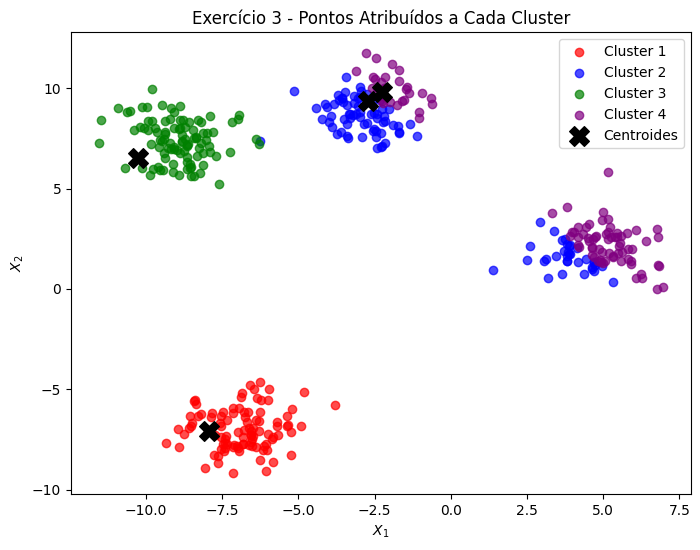

In [6]:
def calcular_distancias(pontos, centroides):
    """Retorna a matriz de distâncias Euclidianas entre cada ponto e cada centróide."""
    dist = np.zeros((pontos.shape[0], centroides.shape[0]))
    for i, c in enumerate(centroides):
        dist[:, i] = np.linalg.norm(pontos - c, axis=1)
    return dist

def atribuir_clusters(pontos, centroides):
    """Atribui a cada ponto o cluster mais próximo."""
    dist = calcular_distancias(pontos, centroides)
    return np.argmin(dist, axis=1)

# Atribuindo os clusters iniciais
clusters_pred = atribuir_clusters(data, centroides)

# Plotando com cores por cluster atribuído
plt.figure(figsize=(8,6))
cores = ['red','blue','green','purple']
for i in range(k):
    plt.scatter(data[clusters_pred == i, 0], data[clusters_pred == i, 1],
                color=cores[i], label=f'Cluster {i+1}', alpha=0.7)
plt.scatter(centroides[:,0], centroides[:,1], color='black', marker='X', s=200, label='Centroides')
plt.title("Exercício 3 - Pontos Atribuídos a Cada Cluster")
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.legend()
plt.show()

## Exercício 4

*   Agora, você tem um grupo de dados já atribuído a cada cluster.
*   Calcule uma nova média em cada cluster.
*   Plote os novos centroides no gráfico.

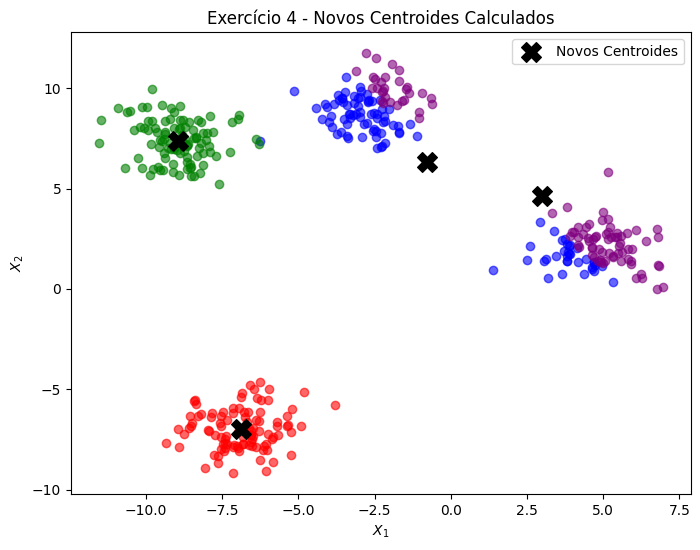

In [7]:
def atualizar_centroides(pontos, clusters, k):
    """Calcula a média dos pontos pertencentes a cada cluster."""
    novos_centroides = np.zeros((k, pontos.shape[1]))
    for i in range(k):
        novos_centroides[i] = pontos[clusters == i].mean(axis=0)
    return novos_centroides

novos_centroides = atualizar_centroides(data, clusters_pred, k)

# Plotando novos centroides
plt.figure(figsize=(8,6))
for i in range(k):
    plt.scatter(data[clusters_pred == i, 0], data[clusters_pred == i, 1], color=cores[i], alpha=0.6)
plt.scatter(novos_centroides[:,0], novos_centroides[:,1], color='black', marker='X', s=200, label='Novos Centroides')
plt.title("Exercício 4 - Novos Centroides Calculados")
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.legend()
plt.show()

## Exercício 5

* Repita o processo a seguir até que perceba que a função erro
não está mais reduzindo (isto é, a média e os clusters não
sofrem mais alterações).

1.   De posse dos novos centroides, reavalie quais amostras pertencem a cada
2.   Calcule uma nova média em cada cluster.

* Plote o resultado final obtido pela função que você implementou
e compare com os clusters gerados pela função make_blobs.

Convergência atingida na iteração 4


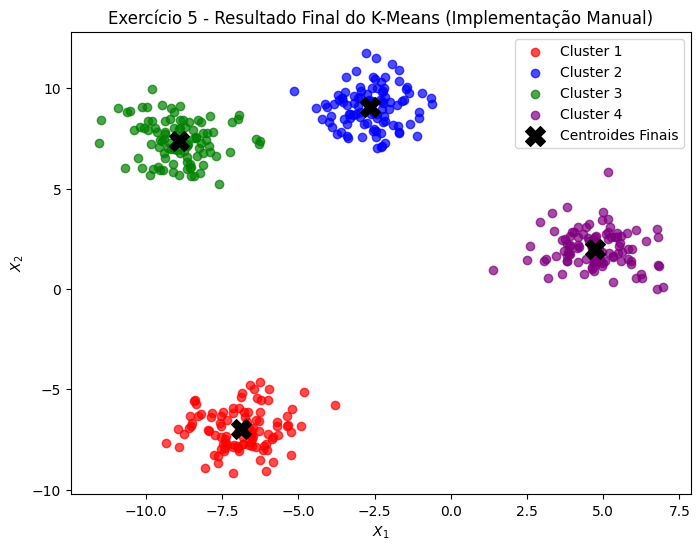


Centroides finais encontrados:
 [[-6.88387179 -6.98398415]
 [-2.63323268  9.04356978]
 [-8.92921104  7.38196067]
 [ 4.74710337  2.01059427]]


In [8]:
def calcular_custo(pontos, centroides, clusters):
    """Função custo: soma das distâncias entre pontos e seus centroides."""
    soma = 0
    for i in range(k):
        soma += np.sum(np.linalg.norm(pontos[clusters == i] - centroides[i], axis=1))
    return soma

# Iterando até convergência
centroides = centroides.copy()
max_iter = 100
tolerancia = 1e-4
for it in range(max_iter):
    clusters_pred = atribuir_clusters(data, centroides)
    novos_centroides = atualizar_centroides(data, clusters_pred, k)

    custo_antigo = calcular_custo(data, centroides, clusters_pred)
    custo_novo = calcular_custo(data, novos_centroides, clusters_pred)

    if abs(custo_antigo - custo_novo) < tolerancia:
        print(f"Convergência atingida na iteração {it+1}")
        break

    centroides = novos_centroides

# Plotando resultado final
plt.figure(figsize=(8,6))
for i in range(k):
    plt.scatter(data[clusters_pred == i, 0], data[clusters_pred == i, 1], color=cores[i], alpha=0.7, label=f'Cluster {i+1}')
plt.scatter(centroides[:,0], centroides[:,1], color='black', marker='X', s=200, label='Centroides Finais')
plt.title("Exercício 5 - Resultado Final do K-Means (Implementação Manual)")
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.legend()
plt.show()

print("\nCentroides finais encontrados:\n", centroides)